# 🧠 Brain Tumor MRI Classifier — Refactored CLI Notebook

This is the **command-line execution** notebook for the PyTorch pipeline.
It is designed to be executed non-interactively with Jupyter/nbconvert and to remain an **orchestration-only layer** that matches `ARCHITECTURE.md`.
All training, evaluation, TensorBoard, checkpoint, Grad-CAM, and Flask logic lives in `notebooks/brain_tumor/`. 


## 0 · Install / Refresh the Project Environment

This cell installs the package in editable mode from the repository root and pulls notebook extras.
Run it once per new environment, or skip it if the environment is already prepared from the shell.


In [1]:
from pathlib import Path
import subprocess, sys

CWD = Path.cwd().resolve()
REPO_ROOT = CWD if (CWD / 'pyproject.toml').exists() else CWD.parent
REQ_FILE = REPO_ROOT / 'requirements.txt'

if REQ_FILE.exists():
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(REQ_FILE)])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-e', f'{REPO_ROOT}[dev,notebook]'])
print(f'✅ Environment refreshed from: {REPO_ROOT}')


✅ Environment refreshed from: /Users/mondo/work/brain-tumor-classifier


## 1 · Configuration

Imports every shared constant from `brain_tumor.config`, then creates the project directories and seeds the run.


In [2]:
from pathlib import Path
import sys

CWD = Path.cwd().resolve()
REPO_ROOT = CWD if (CWD / 'pyproject.toml').exists() else CWD.parent
NOTEBOOKS_DIR = REPO_ROOT / 'notebooks'
for p in [REPO_ROOT, NOTEBOOKS_DIR]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from brain_tumor import config as cfg

DEVICE = cfg.DEVICE
HAS_CUDA = cfg.HAS_CUDA
HAS_MPS = cfg.HAS_MPS
USE_AMP = cfg.USE_AMP
BASE_DIR = cfg.BASE_DIR
DATA_DIR = cfg.DATA_DIR
MODEL_DIR = cfg.MODEL_DIR
REPORT_DIR = cfg.REPORT_DIR
LOG_DIR = cfg.LOG_DIR
TB_LOG_DIR = cfg.TB_LOG_DIR
CKPT_S1 = cfg.CKPT_S1
CKPT_S2 = cfg.CKPT_S2
FINAL_PATH = cfg.FINAL_PATH
TRAIN_ROOT = getattr(cfg, 'TRAIN_ROOT', DATA_DIR / 'Training')
TEST_ROOT = getattr(cfg, 'TEST_ROOT', DATA_DIR / 'Testing')
CLASS_NAMES = cfg.CLASS_NAMES
NUM_CLASSES = cfg.NUM_CLASSES
DATASET_SLUG = cfg.DATASET_SLUG
IMG_SIZE = cfg.IMG_SIZE
IMG_MEAN = cfg.IMG_MEAN
IMG_STD = cfg.IMG_STD
LABEL_MAP = cfg.LABEL_MAP
BATCH_SIZE = cfg.BATCH_SIZE
DROPOUT = cfg.DROPOUT
SEED = cfg.SEED
EPOCHS_S1 = cfg.EPOCHS_S1
LR_S1 = cfg.LR_S1
EPOCHS_S2 = cfg.EPOCHS_S2
LR_S2 = cfg.LR_S2
UNFREEZE_N = cfg.UNFREEZE_N
NUM_WORKERS = cfg.NUM_WORKERS
PIN_MEMORY = cfg.PIN_MEMORY
PERSISTENT_WORKERS = cfg.PERSISTENT_WORKERS
FLASK_HOST = cfg.FLASK_HOST
FLASK_PORT = cfg.FLASK_PORT
seed_everything = cfg.seed_everything
make_dirs = cfg.make_dirs

make_dirs()
seed_everything()

import torch
print(f'Device   : {DEVICE}')
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {HAS_CUDA}' + (f'  ({torch.cuda.get_device_name(0)})' if HAS_CUDA else ''))
print(f'MPS      : {HAS_MPS}')
print(f'AMP      : {USE_AMP}')
print(f'BASE_DIR : {BASE_DIR}')
print(f'TRAIN_ROOT: {TRAIN_ROOT}')
print(f'TEST_ROOT : {TEST_ROOT}')


Device   : mps
PyTorch  : 2.11.0
CUDA     : False
MPS      : True
AMP      : False
BASE_DIR : /Users/mondo/work/brain-tumor-classifier
TRAIN_ROOT: /Users/mondo/work/brain-tumor-classifier/data/brain_tumor_mri/Training
TEST_ROOT : /Users/mondo/work/brain-tumor-classifier/data/brain_tumor_mri/Testing


## 2 · Kaggle Authentication

This cell follows the architecture notes: use an existing `~/.kaggle/kaggle.json`, Colab upload, or a local widget upload.


In [3]:
from pathlib import Path
import json, os, sys
import ipywidgets as widgets
from IPython.display import display, clear_output

KAGGLE_DIR  = Path.home() / '.kaggle'
KAGGLE_JSON = KAGGLE_DIR / 'kaggle.json'
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)

def _save_creds(raw: bytes) -> str:
    creds = json.loads(raw.decode('utf-8'))
    assert 'username' in creds and 'key' in creds, 'Invalid kaggle.json format'
    KAGGLE_JSON.write_text(json.dumps(creds))
    os.chmod(KAGGLE_JSON, 0o600)
    os.environ['KAGGLE_USERNAME'] = creds['username']
    os.environ['KAGGLE_KEY'] = creds['key']
    return creds['username']

if KAGGLE_JSON.exists():
    creds = json.loads(KAGGLE_JSON.read_text())
    os.environ['KAGGLE_USERNAME'] = creds['username']
    os.environ['KAGGLE_KEY'] = creds['key']
    print(f'✅ Using existing kaggle.json for: {creds["username"]}')

elif 'google.colab' in sys.modules:
    from google.colab import files
    uploaded = files.upload()
    if 'kaggle.json' in uploaded:
        user = _save_creds(uploaded['kaggle.json'])
        print(f'✅ Uploaded kaggle.json for: {user}')
    else:
        print('⚠️ Upload kaggle.json to enable dataset download.')

else:
    uploader = widgets.FileUpload(accept='.json', multiple=False)
    out = widgets.Output()

    def _on_upload(change):
        if not uploader.value:
            return
        file_info = list(uploader.value)[0] if isinstance(uploader.value, dict) else uploader.value[0]
        raw = file_info['content'] if isinstance(file_info, dict) else file_info.content.tobytes()
        with out:
            clear_output(wait=True)
            try:
                user = _save_creds(raw)
                print(f'✅ Saved kaggle.json for: {user}')
            except Exception as exc:
                print(f'❌ Kaggle credential error: {exc}')

    uploader.observe(_on_upload, names='value')
    display(widgets.VBox([widgets.HTML('<b>Upload kaggle.json</b>'), uploader, out]))


✅ Using existing kaggle.json for: mondosoria


## 3 · Download & Inspect Dataset


In [4]:
import importlib, os, sys
from pathlib import Path

import brain_tumor.config as cfg_mod
import brain_tumor.data.dataset as ds

# Reload modules to pick up any local edits.
importlib.reload(cfg_mod)
importlib.reload(ds)

# Guard: confirm credentials are in the environment.
_username = os.environ.get('KAGGLE_USERNAME', '').strip()
_key = os.environ.get('KAGGLE_KEY', '').strip()

if not _username or not _key:
    raise RuntimeError(
        'Kaggle credentials not found in the environment. '
        'Run Section 2 (Kaggle Authentication) first and ensure you see the '
        'confirmation message before running this cell.'
    )
print(f'Credentials present for: {_username}')

# Resolve project root + data directory.
cfg_path = Path(cfg_mod.__file__).resolve()
repo_root = next(
    (p for p in [cfg_path.parent, *cfg_path.parent.parents] if (p / 'pyproject.toml').exists()),
    Path.cwd().resolve(),
)

# DATA_DIR from config points to <root>/data/brain_tumor_mri.
data_dir = Path(cfg_mod.DATA_DIR).resolve()

print(f'Config module : {cfg_path}')
print(f'Dataset module: {Path(ds.__file__).resolve()}')
print(f'DATA_DIR      : {data_dir}')
print(f'DATASET_SLUG  : {cfg_mod.DATASET_SLUG}')

# Download (skipped if data directory already exists).
TRAIN_ROOT, TEST_ROOT = ds.download_dataset(data_dir, cfg_mod.DATASET_SLUG)

# Expose roots to later cells.
print(f'Train root exists : {TRAIN_ROOT.exists()}')
print(f'Test  root exists : {TEST_ROOT.exists()}')
print(f'Classes           : {cfg_mod.CLASS_NAMES}')
print(f'Label map keys    : {sorted(cfg_mod.LABEL_MAP.keys())}')

Credentials present for: mondosoria
Config module : /Users/mondo/work/brain-tumor-classifier/brain_tumor/config.py
Dataset module: /Users/mondo/work/brain-tumor-classifier/brain_tumor/data/dataset.py
DATA_DIR      : /Users/mondo/work/brain-tumor-classifier/data/brain_tumor_mri
DATASET_SLUG  : masoudnickparvar/brain-tumor-mri-dataset
Dataset already present ✔  (/Users/mondo/work/brain-tumor-classifier/data/brain_tumor_mri)

Train root : /Users/mondo/work/brain-tumor-classifier/data/brain_tumor_mri/Training
Test root  : /Users/mondo/work/brain-tumor-classifier/data/brain_tumor_mri/Testing

Class distribution:
  Train/glioma                 1400 images
  Train/meningioma             1400 images
  Train/notumor                1400 images
  Train/pituitary              1400 images
  Test/glioma                  400 images
  Test/meningioma              400 images
  Test/notumor                 400 images
  Test/pituitary               400 images
Train root exists : True
Test  root exists : 

## 4 · Dataset, Augmentation & DataLoaders


Train :  4760 images  (149 batches)
Val   :   840 images  (27 batches)
Test  :  1600 images  (50 batches)
pin_memory=False  num_workers=0  persistent_workers=False


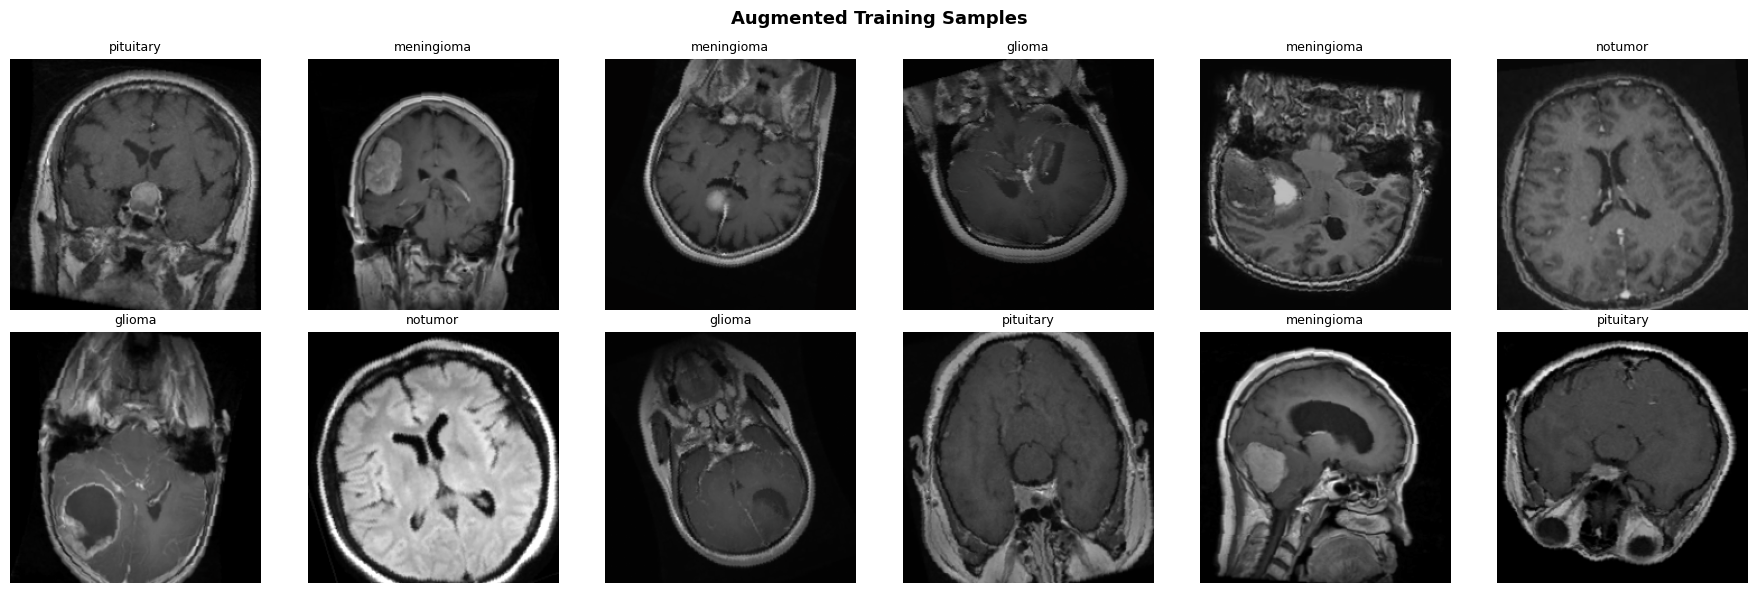

In [5]:
from brain_tumor.data.dataset import build_dataloaders, get_val_transform
from brain_tumor.evaluation.plots import plot_augmented_samples

train_loader, val_loader, test_loader, full_train_aug = build_dataloaders(
    TRAIN_ROOT, TEST_ROOT
)
val_transform = get_val_transform()

print(f'Train : {len(train_loader.dataset):>5} images  ({len(train_loader)} batches)')
print(f'Val   : {len(val_loader.dataset):>5} images  ({len(val_loader)} batches)')
print(f'Test  : {len(test_loader.dataset):>5} images  ({len(test_loader)} batches)')
print(f'pin_memory={PIN_MEMORY}  num_workers={NUM_WORKERS}  persistent_workers={PERSISTENT_WORKERS}')
plot_augmented_samples(train_loader)


## 5 · Class-Weight Computation


In [6]:
from brain_tumor.evaluation.metrics import compute_class_weights

class_weights = compute_class_weights(
    full_train_aug,
    train_loader.dataset.indices,
)
print('Class weights:', class_weights)


Class weights:
  [0] glioma       count=1174  weight=1.0136
  [1] meningioma   count=1178  weight=1.0102
  [2] pituitary    count=1202  weight=0.9900
  [3] notumor      count=1206  weight=0.9867
Class weights: tensor([1.0136, 1.0102, 0.9900, 0.9867], device='mps:0')


## 6 · Model — EfficientNetB0


In [7]:
from brain_tumor.models.classifier import BrainTumorClassifier

model = BrainTumorClassifier(NUM_CLASSES, DROPOUT).to(DEVICE)
print(f'Total params    : {model.n_total:,}')
print(f'Trainable params: {model.n_trainable:,}')


Loaded pretrained weights for efficientnet-b0
Total params    : 4,339,584
Trainable params: 4,339,584


## 7 · TensorBoard Setup


In [8]:
from brain_tumor.training.tensorboard import setup_writer, launch_tensorboard

writer = setup_writer(model)
tb_proc = launch_tensorboard()
print(f'📊 TensorBoard logdir: {TB_LOG_DIR}')
print('🛑 Stop later with: tb_proc.terminate()')


TensorBoard writer → /Users/mondo/work/brain-tumor-classifier/runs/brain_tumor
Model graph logged to TensorBoard.
tensorboard binary : /Users/mondo/work/brain-tumor-classifier/.venv/bin/tensorboard
Log dir            : /Users/mondo/work/brain-tumor-classifier/runs/brain_tumor
Exists             : True
Files              : ['events.out.tfevents.1775773973.Armandos-MacBook-Pro.local.56708.0']
✅ TensorBoard running → http://127.0.0.1:6006
   (allow a few seconds, then refresh if graphs are empty)
   Stop with: tb_proc.terminate()
📊 TensorBoard logdir: /Users/mondo/work/brain-tumor-classifier/runs/brain_tumor
🛑 Stop later with: tb_proc.terminate()


## 8 · Stage 1 — Frozen Backbone


In [9]:
import torch.nn as nn
import torch.optim as optim
from brain_tumor.training.engine import run_stage

model.freeze_backbone()
print(f'Trainable params (Stage 1): {model.n_trainable:,}')

criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_S1)
scheduler1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer1, mode='min', factor=0.4, patience=4)

history_s1 = run_stage(
    model, train_loader, val_loader,
    criterion, optimizer1, scheduler1,
    EPOCHS_S1, 'S1-frozen', CKPT_S1,
    tb_writer=writer, global_step_offset=0,
)
print(f'✅ Stage 1 complete → {CKPT_S1}')


Trainable params (Stage 1): 332,036


S1-frozen | Epoch 01/15 | train_loss=0.6108 train_acc=0.7664 | val_loss=0.4558 val_acc=0.8345  ← best


S1-frozen | Epoch 02/15 | train_loss=0.4898 train_acc=0.8227 | val_loss=0.6032 val_acc=0.7536


S1-frozen | Epoch 03/15 | train_loss=0.4734 train_acc=0.8218 | val_loss=0.4794 val_acc=0.8131


S1-frozen | Epoch 04/15 | train_loss=0.4400 train_acc=0.8349 | val_loss=0.4152 val_acc=0.8631  ← best


...

S1-frozen | Epoch 11/15 | train_loss=0.3869 train_acc=0.8502 | val_loss=0.3515 val_acc=0.8667


S1-frozen | Epoch 12/15 | train_loss=0.3946 train_acc=0.8519 | val_loss=0.3433 val_acc=0.8786


S1-frozen | Epoch 13/15 | train_loss=0.3727 train_acc=0.8597 | val_loss=0.3151 val_acc=0.8845


S1-frozen | Epoch 14/15 | train_loss=0.3653 train_acc=0.8620 | val_loss=0.3199 val_acc=0.8905  ← best


S1-frozen | Epoch 15/15 | train_loss=0.3655 train_acc=0.8559 | val_loss=0.3245 val_acc=0.8881
✅ Stage 1 complete → /Users/mondo/work/brain-tumor-classifier/models/best_stage1.pth


## 9 · Stage 2 — Fine-tune Last 30 Layers


In [10]:
import torch

model.load_state_dict(torch.load(CKPT_S1, map_location=DEVICE))
model.unfreeze_last_n(UNFREEZE_N)
print(f'Trainable params (Stage 2): {model.n_trainable:,}')

optimizer2 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_S2)
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='min', factor=0.4, patience=4)

history_s2 = run_stage(
    model, train_loader, val_loader,
    criterion, optimizer2, scheduler2,
    EPOCHS_S2, 'S2-finetune', CKPT_S2,
    tb_writer=writer,
    global_step_offset=len(history_s1['train_loss']),
)
writer.flush(); writer.close()
print(f'✅ Stage 2 complete → {CKPT_S2}')


Trainable params (Stage 2): 1,739,492


S2-finetune | Epoch 01/25 | train_loss=0.3390 train_acc=0.8712 | val_loss=0.2910 val_acc=0.9012  ← best


S2-finetune | Epoch 02/25 | train_loss=0.3076 train_acc=0.8805 | val_loss=0.2720 val_acc=0.9036  ← best


S2-finetune | Epoch 03/25 | train_loss=0.2813 train_acc=0.8924 | val_loss=0.2541 val_acc=0.9095  ← best


S2-finetune | Epoch 04/25 | train_loss=0.2811 train_acc=0.8950 | val_loss=0.2438 val_acc=0.9155  ← best


...

S2-finetune | Epoch 21/25 | train_loss=0.1595 train_acc=0.9395 | val_loss=0.1613 val_acc=0.9405  ← best


S2-finetune | Epoch 22/25 | train_loss=0.1533 train_acc=0.9424 | val_loss=0.1586 val_acc=0.9440  ← best


S2-finetune | Epoch 23/25 | train_loss=0.1641 train_acc=0.9395 | val_loss=0.1592 val_acc=0.9357


S2-finetune | Epoch 24/25 | train_loss=0.1493 train_acc=0.9420 | val_loss=0.1585 val_acc=0.9440


S2-finetune | Epoch 25/25 | train_loss=0.1573 train_acc=0.9395 | val_loss=0.1632 val_acc=0.9440
✅ Stage 2 complete → /Users/mondo/work/brain-tumor-classifier/models/best_stage2.pth


## 10 · Training Curves


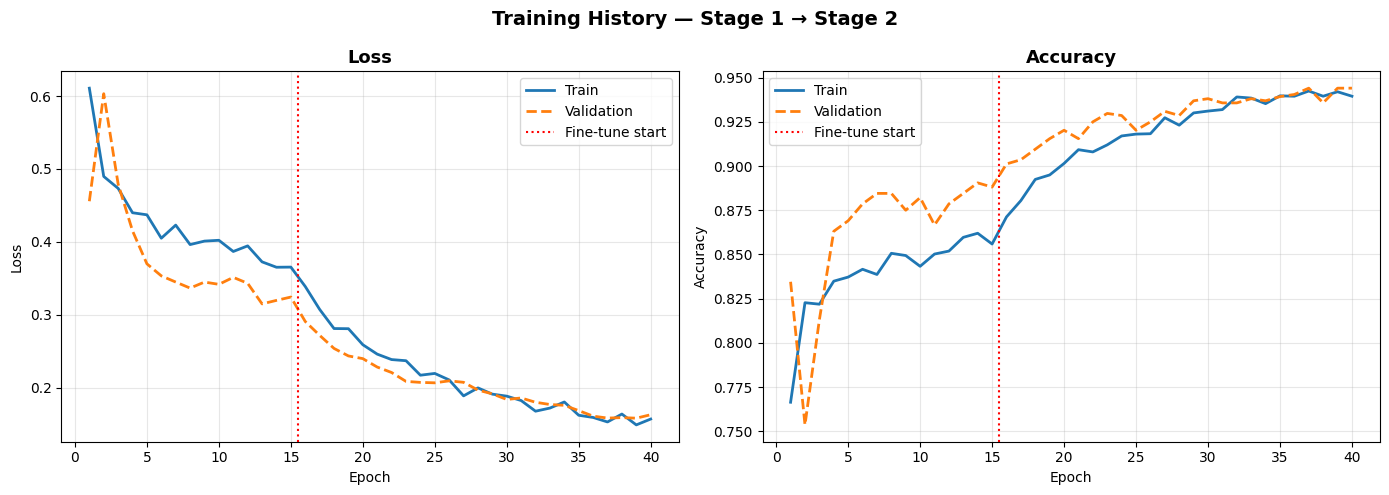

In [11]:
from brain_tumor.evaluation.plots import plot_history

plot_history(history_s1, history_s2)


## 11 · Test Evaluation


In [12]:
from brain_tumor.models.classifier import BrainTumorClassifier
from brain_tumor.evaluation.metrics import get_predictions, print_classification_report

best_model = BrainTumorClassifier(NUM_CLASSES, DROPOUT).to(DEVICE)
best_model.load_state_dict(torch.load(CKPT_S2, map_location=DEVICE))
best_model.eval()

y_true, y_pred, y_prob, img_paths = get_predictions(best_model, test_loader)
print_classification_report(y_true, y_pred)


Loaded pretrained weights for efficientnet-b0


Predicting: 100%|██████████| 50/50 [00:14<00:00,  3.37it/s]

Classification Report:

              precision    recall  f1-score   support

      glioma     0.9711    0.7550    0.8495       400
  meningioma     0.8501    0.9075    0.8779       400
   pituitary     0.9450    0.9875    0.9658       400
     notumor     0.8941    0.9925    0.9408       400

    accuracy                         0.9106      1600
   macro avg     0.9151    0.9106    0.9085      1600
weighted avg     0.9151    0.9106    0.9085      1600



## 12 · Confusion Matrix


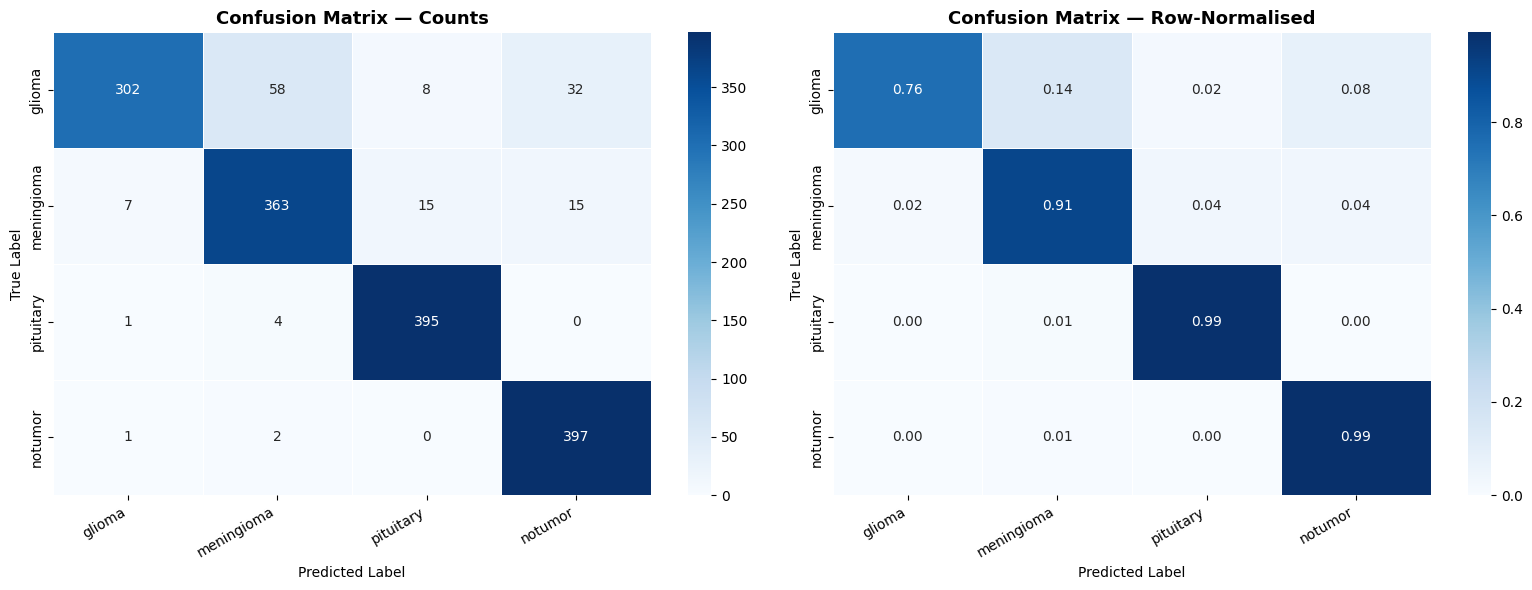

In [13]:
from brain_tumor.evaluation.plots import plot_confusion_matrix

plot_confusion_matrix(y_true, y_pred)


## 13 · Per-Class ROC Curves


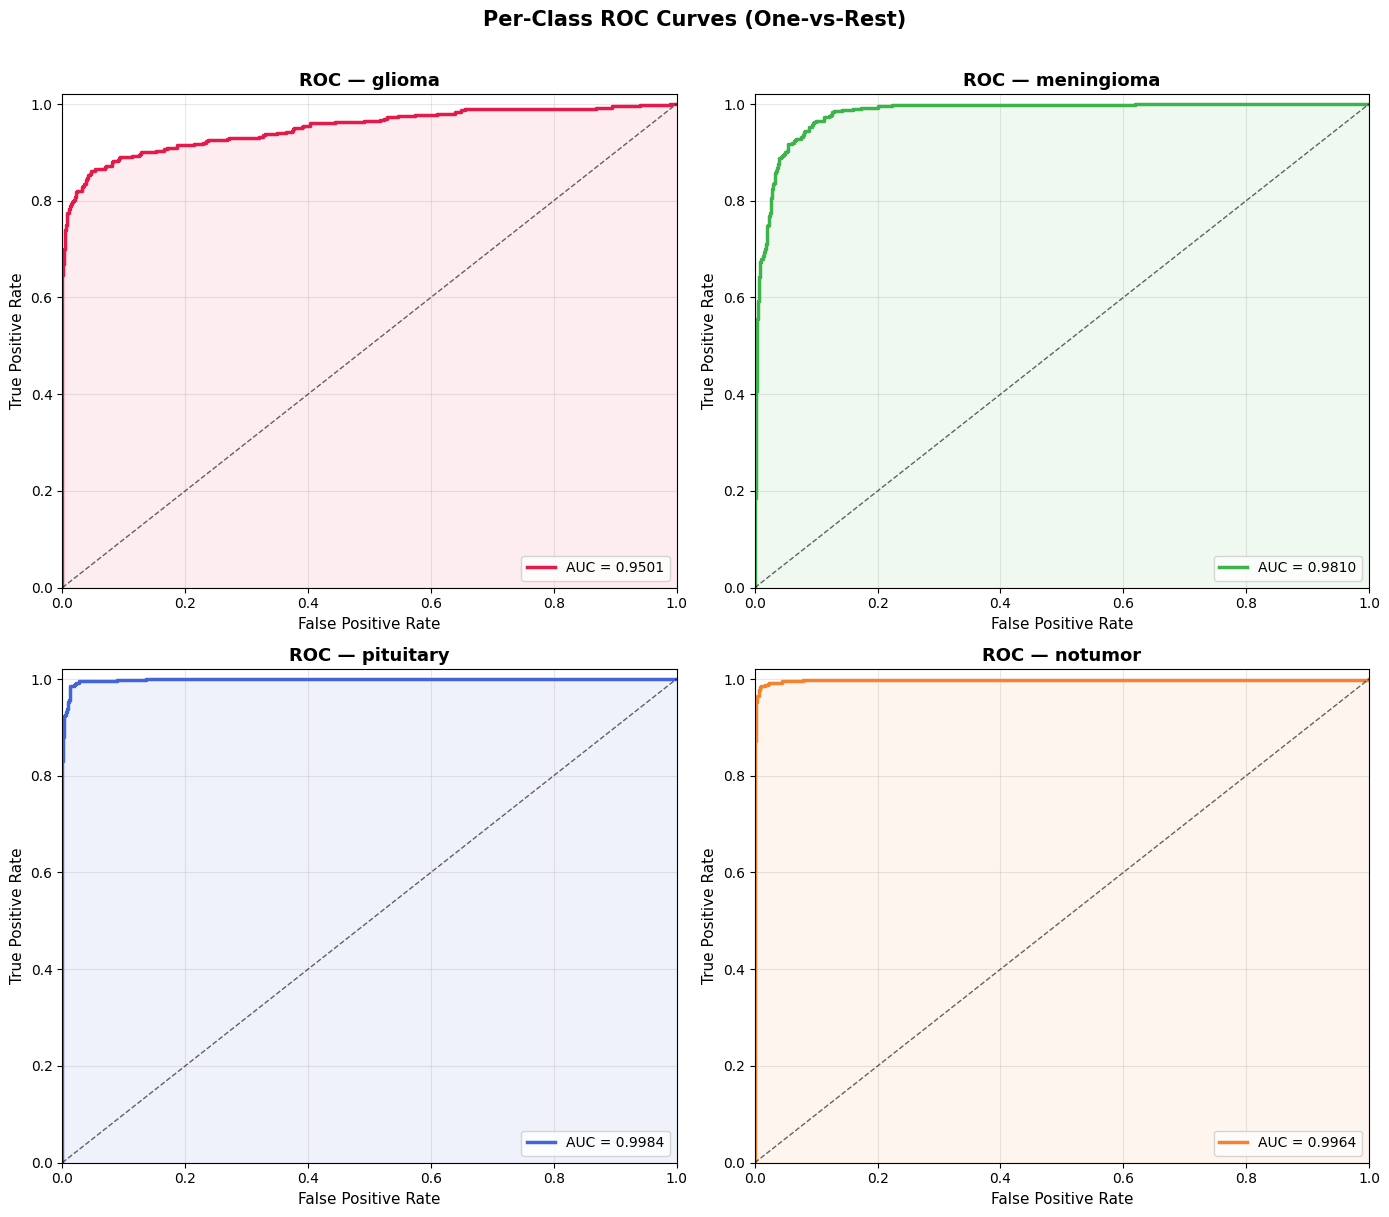

Macro-average AUC: 0.9815
ROC scores: {'glioma': 0.9500770833333333, 'meningioma': 0.9810375000000001, 'pituitary': 0.99838125, 'notumor': 0.9963791666666667}


In [14]:
from brain_tumor.evaluation.plots import plot_roc_curves

roc_scores = plot_roc_curves(y_true, y_prob)
print('ROC scores:', roc_scores)


## 14 · Misclassification Review


Misclassified: 143 / 1600


,path,true_label,pred_label,pred_confidence,true_confidence
0,/Users/mondo/work/brain-tumor-classifier/data/...,glioma,notumor,0.676337,2.052410e-04
1,/Users/mondo/work/brain-tumor-classifier/data/...,glioma,notumor,0.846848,3.356458e-04
2,/Users/mondo/work/brain-tumor-classifier/data/...,glioma,meningioma,0.852185,1.469849e-01
3,/Users/mondo/work/brain-tumor-classifier/data/...,glioma,meningioma,0.686722,3.127283e-01
4,/Users/mondo/work/brain-tumor-classifier/data/...,glioma,notumor,0.673720,1.643151e-03
5,/Users/mondo/work/brain-tumor-classifier/data/...,glioma,meningioma,0.967883,2.732420e-03
6,/Users/mondo/work/brain-tumor-classifier/data/...,glioma,meningioma,0.627854,3.209816e-04
7,/Users/mondo/work/brain-tumor-classifier/data/...,glioma,meningioma,0.765614,2.337482e-01
8,/Users/mondo/work/brain-tumor-classifier/data/...,glioma,meningioma,0.899001,8.411676e-02
9,/Users/mondo/work/brain-tumor-classifier/data/...,glioma,meningioma,0.888849,8.843267e-02


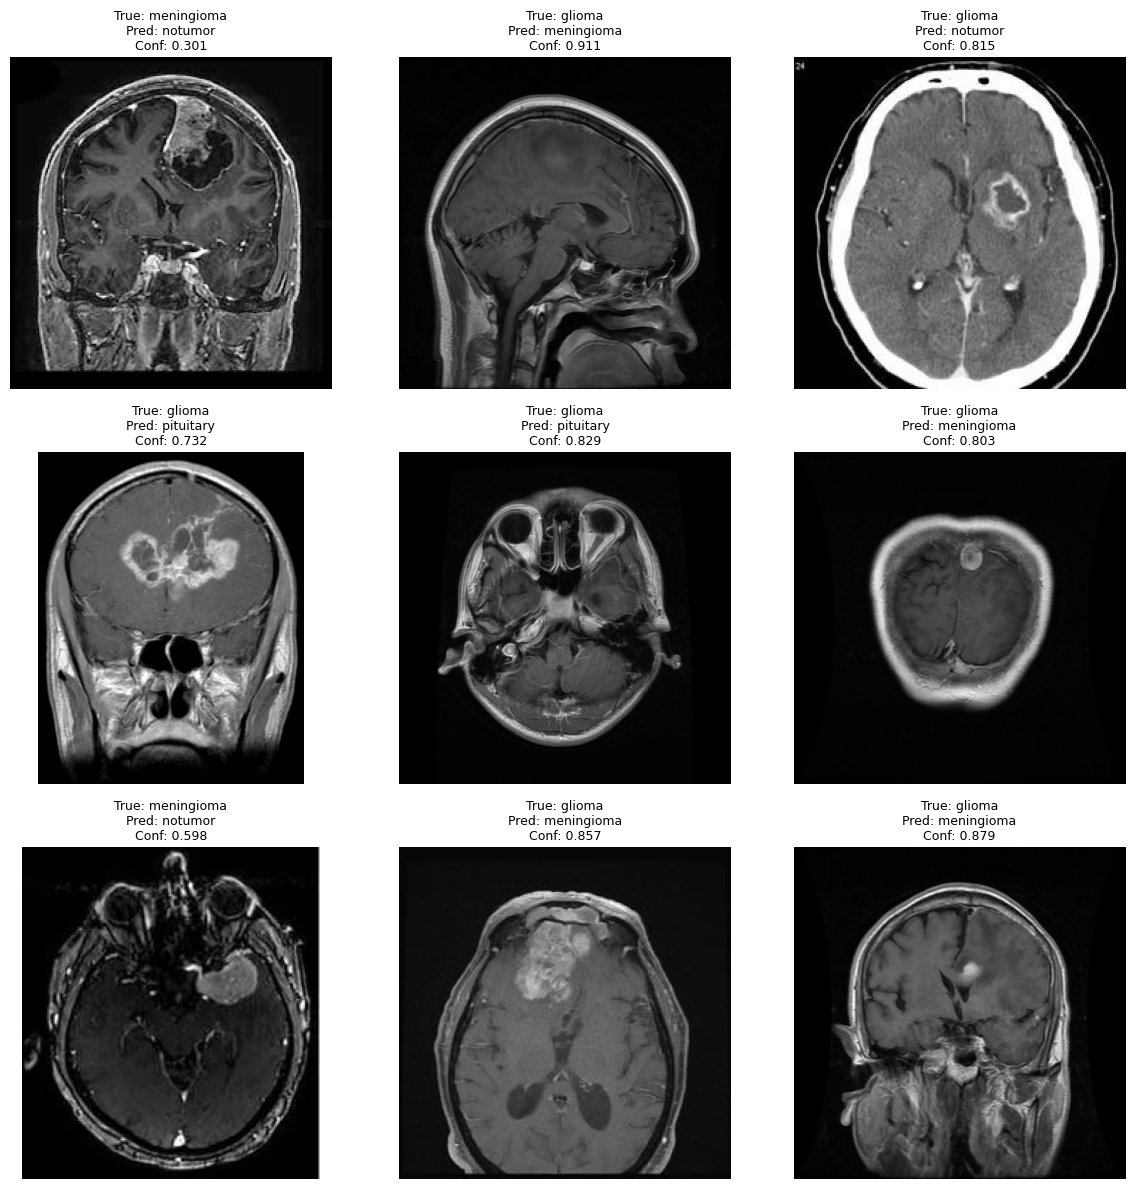

In [15]:
from brain_tumor.evaluation.plots import plot_misclassified
from brain_tumor.evaluation.metrics import build_error_dataframe

errors_df = build_error_dataframe(y_true, y_pred, y_prob, img_paths)
display(errors_df.head(20))
plot_misclassified(errors_df)


## 15 · Grad-CAM Visualisation


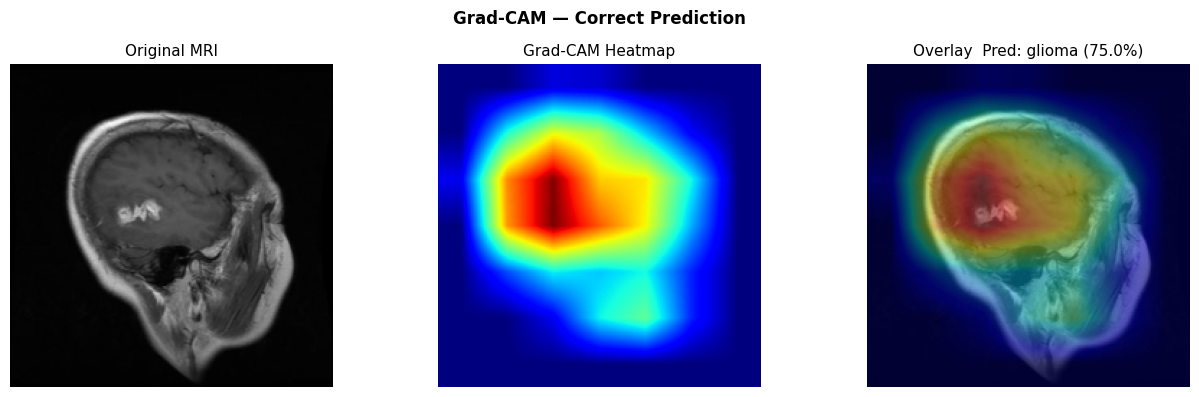

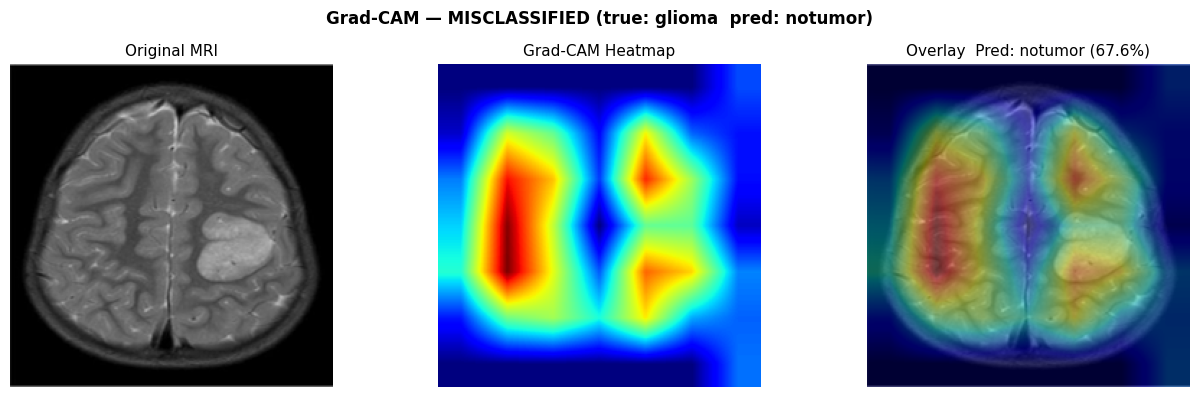

In [16]:
from brain_tumor.evaluation.gradcam import display_gradcam

correct_idx = next(i for i in range(len(y_true)) if y_true[i] == y_pred[i])
display_gradcam(
    img_paths[correct_idx], best_model, val_transform,
    title_prefix='Grad-CAM — Correct Prediction',
)

if len(errors_df) > 0:
    row = errors_df.iloc[0]
    display_gradcam(
        row['path'], best_model, val_transform,
        title_prefix=f'Grad-CAM — MISCLASSIFIED (true: {row["true_label"]}  pred: {row["pred_label"]})',
    )
else:
    print('No misclassified cases to visualise.')


## 16 · Save Model & Metrics


In [17]:
import numpy as np
from brain_tumor.models.checkpoint import save_model, save_metrics

save_model(best_model, FINAL_PATH)

macro_auc = float(np.mean(list(roc_scores.values())))
metrics_payload = {
    'macro_auc'    : macro_auc,
    'roc_per_class': {k: float(v) for k, v in roc_scores.items()},
    'total_test'   : int(len(y_true)),
    'misclassified': int(len(errors_df)),
}
save_metrics(metrics_payload)
print(metrics_payload)


Model saved → /Users/mondo/work/brain-tumor-classifier/models/brain_tumor_efficientnetb0_final.pth  (17.7 MB)
Metrics saved → /Users/mondo/work/brain-tumor-classifier/reports/metrics_summary.json
{'macro_auc': 0.98146875, 'roc_per_class': {'glioma': 0.9500770833333333, 'meningioma': 0.9810375000000001, 'pituitary': 0.99838125, 'notumor': 0.9963791666666667}, 'total_test': 1600, 'misclassified': 143}


## 17 · Flask Inference App


In [18]:
import os, sys, time, subprocess, urllib.request

FLASK_URL    = f'http://{FLASK_HOST}:{FLASK_PORT}'
FLASK_HEALTH = f'{FLASK_URL}/health'
FLASK_LOG    = LOG_DIR / 'flask_server.log'
flask_script = BASE_DIR / 'src' / 'app' / 'app.py'

try:
    if 'flask_proc' in globals() and flask_proc and flask_proc.poll() is None:
        flask_proc.terminate(); time.sleep(1)
except Exception:
    pass

env = os.environ.copy()
env['PYTHONUNBUFFERED'] = '1'
log_fh = open(FLASK_LOG, 'w', buffering=1)
flask_proc = subprocess.Popen(
    [sys.executable, '-u', str(flask_script)],
    stdout=log_fh, stderr=subprocess.STDOUT,
    text=True, cwd=str(flask_script.parent), env=env,
)

healthy = False
for _ in range(30):
    if flask_proc.poll() is not None:
        break
    try:
        urllib.request.urlopen(FLASK_HEALTH, timeout=1.5)
        healthy = True
        break
    except Exception:
        time.sleep(0.5)

if healthy:
    print(f'✅ Flask running → {FLASK_URL}')
    print(f'📝 Logs: {FLASK_LOG}')
    print('🛑 Stop later with: flask_proc.terminate()')
else:
    print('❌ Flask did not start. Check logs:')
    print(FLASK_LOG.read_text()[-3000:])


✅ Flask running → http://127.0.0.1:5001
📝 Logs: /Users/mondo/work/brain-tumor-classifier/logs/flask_server.log
🛑 Stop later with: flask_proc.terminate()


## 18 · Optional · Shutdown


In [19]:
ENABLE_FLASK_STOP = False
if ENABLE_FLASK_STOP and 'flask_proc' in globals() and flask_proc and flask_proc.poll() is None:
    import time
    flask_proc.terminate()
    time.sleep(1)
    print('Flask stopped.')


In [20]:
ENABLE_TB_STOP = False
if ENABLE_TB_STOP and 'tb_proc' in globals() and tb_proc and tb_proc.poll() is None:
    import time
    tb_proc.terminate()
    time.sleep(1)
    print('TensorBoard stopped.')


## 19 · Output Artefact Inventory


In [21]:
import pandas as pd

inventory = [
    {'path': str(p.relative_to(BASE_DIR)), 'size_kb': round(p.stat().st_size / 1024, 2)}
    for root in [MODEL_DIR, REPORT_DIR, LOG_DIR]
    for p in sorted(root.rglob('*')) if p.is_file()
]
display(pd.DataFrame(inventory))


,path,size_kb
0,models/best_stage1.pth,17255.00
1,models/best_stage2.pth,17255.00
2,models/brain_tumor_efficientnetb0_final.pth,17263.44
3,reports/confusion_matrix.png,66.69
4,reports/metrics_summary.json,0.23
5,reports/misclassified.csv,20.84
6,reports/misclassified_panel.png,796.55
7,reports/roc_curves.png,121.14
8,reports/sample_augmented.png,647.82
9,reports/training_curves.png,93.99


---

This notebook is intentionally thin. If you need to change training logic, update the package modules under `notebooks/brain_tumor/`, not the notebook cells. See `ARCHITECTURE.md` for the module ownership map.
